# Assignment: Naive Bayes

Nama: Faris Akmal Soehartono

NRP 3124600101

Kelas: 3 D4 IT D

Import library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

from sklearn.naive_bayes import (
    GaussianNB,
    MultinomialNB,
    BernoulliNB,
    ComplementNB,
    CategoricalNB
)

### 1. Load Dataset

Membaca isi dataset

In [2]:
df = pd.read_csv("breast_cancer.csv")

print("Ukuran dataset:", df.shape)
print("\n5 data pertama:")
print(df.head())


print("\nInformasi dataset:")
print(df.info())

Ukuran dataset: (569, 33)

5 data pertama:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_wor

Distribusi diagnosis

In [3]:

print("\nDistribusi diagnosis:")
print(df["diagnosis"].value_counts())


Distribusi diagnosis:
diagnosis
B    357
M    212
Name: count, dtype: int64


### 2. Preprocessing

Menghilangkan Missing Values

Drop ID karena tidak digunakan sebagai fitur

Drop Unnamed 32 karena berisi missing values

In [4]:
X = df.drop(columns=["id", "Unnamed: 32", "diagnosis"])
y = df["diagnosis"]

Konversi label Malignant (1) dan Benign (0)

In [5]:
y = y.map({"B": 0, "M": 1})

In [6]:
print("\nJumlah fitur:", X.shape[1])
print("Shape X:", X.shape)
print("Shape y:", y.shape)


Jumlah fitur: 30
Shape X: (569, 30)
Shape y: (569,)


### 3. Split Dataset

Splitting Dataset dengan distribusi 80:20 untuk masing masing train dan test data

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining set:", X_train.shape)
print("Testing set :", X_test.shape)


Training set: (455, 30)
Testing set : (114, 30)


### 4. Naive Bayes tanpa Normalisasi

In [8]:
models = {
    "GaussianNB": GaussianNB(),
    "MultinomialNB": MultinomialNB(),
    "BernoulliNB": BernoulliNB(),
    "ComplementNB": ComplementNB(),
    "CategoricalNB": CategoricalNB()
}

results_without_scaling = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results_without_scaling[name] = accuracy

    print(f"{name}: {accuracy:.4f}")

GaussianNB: 0.9386
MultinomialNB: 0.8947
BernoulliNB: 0.6316
ComplementNB: 0.8947
CategoricalNB: 0.9035


### 5. Naive Bayes dengan Normalisasi MinMaxScaller

In [9]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results_with_scaling = {}

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)

    results_with_scaling[name] = accuracy

    print(f"{name}: {accuracy:.4f}")

GaussianNB: 0.9211
MultinomialNB: 0.8246
BernoulliNB: 0.6404
ComplementNB: 0.8158
CategoricalNB: 0.6316


### 6. Membandingkan Hasil

In [10]:
comparison = pd.DataFrame({
    "Metode": list(models.keys()),
    "Tanpa Normalisasi": [
        results_without_scaling[name]
        for name in models.keys()
    ],
    "Dengan MinMaxScaler": [
        results_with_scaling[name]
        for name in models.keys()
    ]
})

print("\nPerbandingan Accuracy:")
print(comparison.to_string(index=False))


Perbandingan Accuracy:
       Metode  Tanpa Normalisasi  Dengan MinMaxScaler
   GaussianNB           0.938596             0.921053
MultinomialNB           0.894737             0.824561
  BernoulliNB           0.631579             0.640351
 ComplementNB           0.894737             0.815789
CategoricalNB           0.903509             0.631579


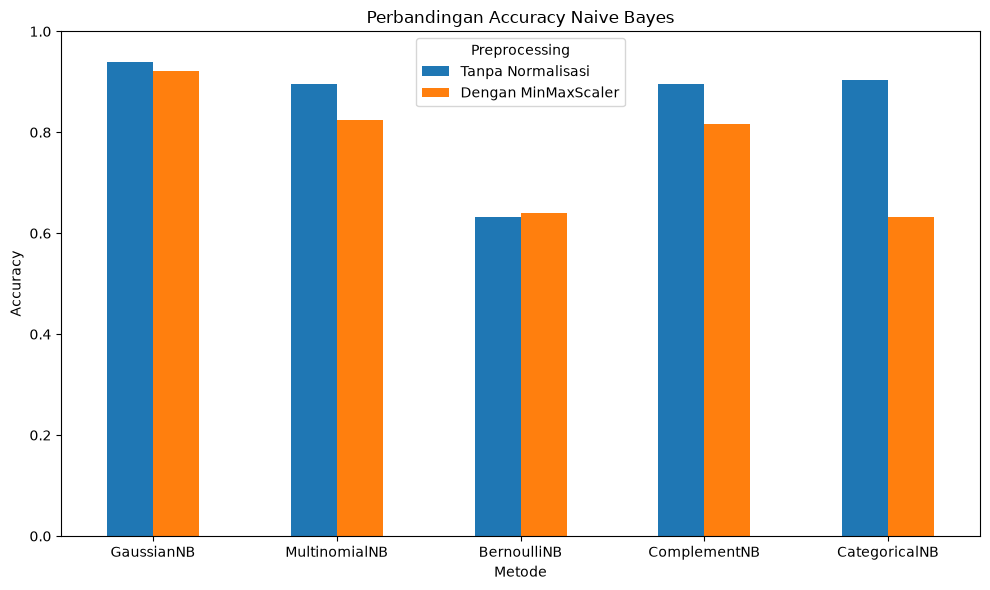

In [11]:
comparison.set_index("Metode").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Perbandingan Accuracy Naive Bayes")
plt.xlabel("Metode")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Preprocessing")
plt.tight_layout()
plt.show()

### 7. Mencari Model Terbaik

In [12]:
best_without_scaling = max(
    results_without_scaling,
    key=results_without_scaling.get
)

best_with_scaling = max(
    results_with_scaling,
    key=results_with_scaling.get
)

print("\nModel terbaik tanpa normalisasi:")
print(
    best_without_scaling,
    results_without_scaling[best_without_scaling]
)

print("\nModel terbaik dengan normalisasi:")
print(
    best_with_scaling,
    results_with_scaling[best_with_scaling]
)


Model terbaik tanpa normalisasi:
GaussianNB 0.9385964912280702

Model terbaik dengan normalisasi:
GaussianNB 0.9210526315789473


In [13]:
all_results = {}

for name, accuracy in results_without_scaling.items():
    all_results[f"{name} (Tanpa Normalisasi)"] = accuracy

for name, accuracy in results_with_scaling.items():
    all_results[f"{name} (MinMaxScaler)"] = accuracy

best_model_name = max(
    all_results,
    key=all_results.get
)

best_accuracy = all_results[best_model_name]

print("\nModel Naive Bayes terbaik:")
print(best_model_name)
print(f"Accuracy: {best_accuracy:.4f}")


Model Naive Bayes terbaik:
GaussianNB (Tanpa Normalisasi)
Accuracy: 0.9386


### 8. Test Single Input

In [14]:
single_input = [[
    17.99, 10.38, 122.8, 1001, 0.1184,
    0.2776, 0.3001, 0.1471, 0.2419, 0.07871,
    1.095, 0.9053, 8.589, 153.4, 0.006399,
    0.04904, 0.05373, 0.01587, 0.03003, 0.006193,
    25.38, 17.33, 184.6, 2019, 0.1622,
    0.6656, 0.7119, 0.2654, 0.4601, 0.1189
]]

single_input = pd.DataFrame(
    single_input,
    columns=X_train.columns
)

if "MinMaxScaler" in best_model_name:

    best_model_type = best_model_name.replace(
        " (MinMaxScaler)", ""
    )

    best_model = models[best_model_type]

    best_model.fit(X_train_scaled, y_train)

    single_input_scaled = scaler.transform(single_input)

    prediction = best_model.predict(single_input_scaled)

else:

    best_model_type = best_model_name.replace(
        " (Tanpa Normalisasi)", ""
    )

    best_model = models[best_model_type]

    best_model.fit(X_train, y_train)

    prediction = best_model.predict(single_input)


if prediction[0] == 0:
    diagnosis = "Benign (B)"
else:
    diagnosis = "Malignant (M)"

print("\nHasil Single Input:")
print("Prediksi:", diagnosis)


Hasil Single Input:
Prediksi: Malignant (M)
